In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv('Banking_churn_prediction.csv')

# Basic inspection
print("Data Info:")
print(df.info())
print("\nFirst 5 rows:")
print(df.head())
print("\nMissing values:")
print(df.isnull().sum())
print("\nSummary Statistics:")
print(df.describe())

Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28382 entries, 0 to 28381
Data columns (total 21 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   customer_id                     28382 non-null  int64  
 1   vintage                         28382 non-null  int64  
 2   age                             28382 non-null  int64  
 3   gender                          27857 non-null  object 
 4   dependents                      25919 non-null  float64
 5   occupation                      28302 non-null  object 
 6   city                            27579 non-null  float64
 7   customer_nw_category            28382 non-null  int64  
 8   branch_code                     28382 non-null  int64  
 9   current_balance                 28382 non-null  float64
 10  previous_month_end_balance      28382 non-null  float64
 11  average_monthly_balance_prevQ   28382 non-null  float64
 12  average_monthly_balan

EDA plots generated.


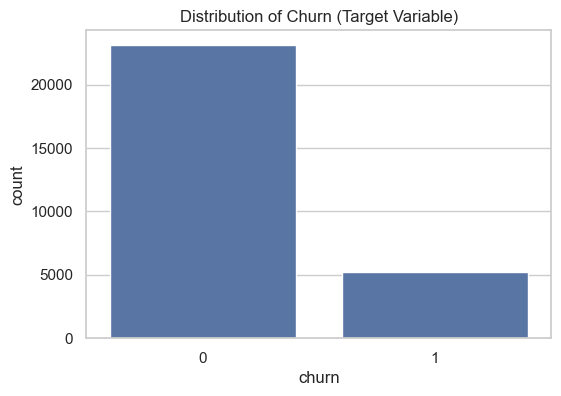

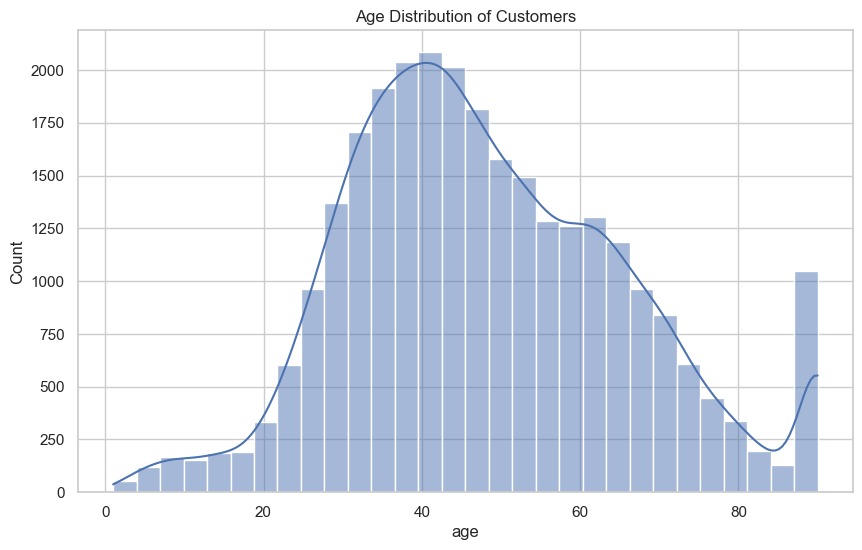

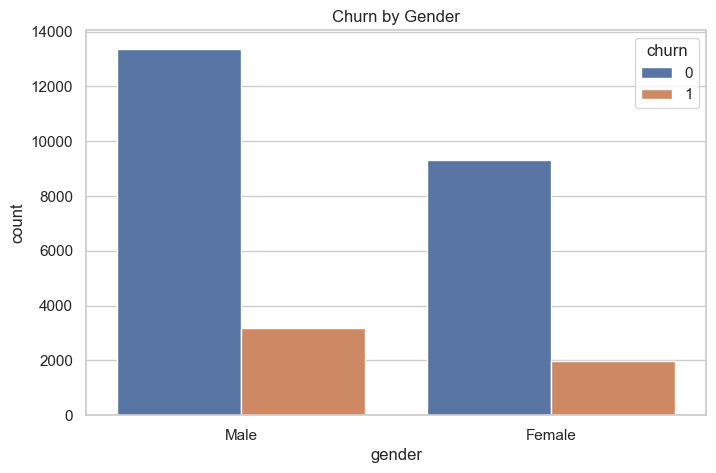

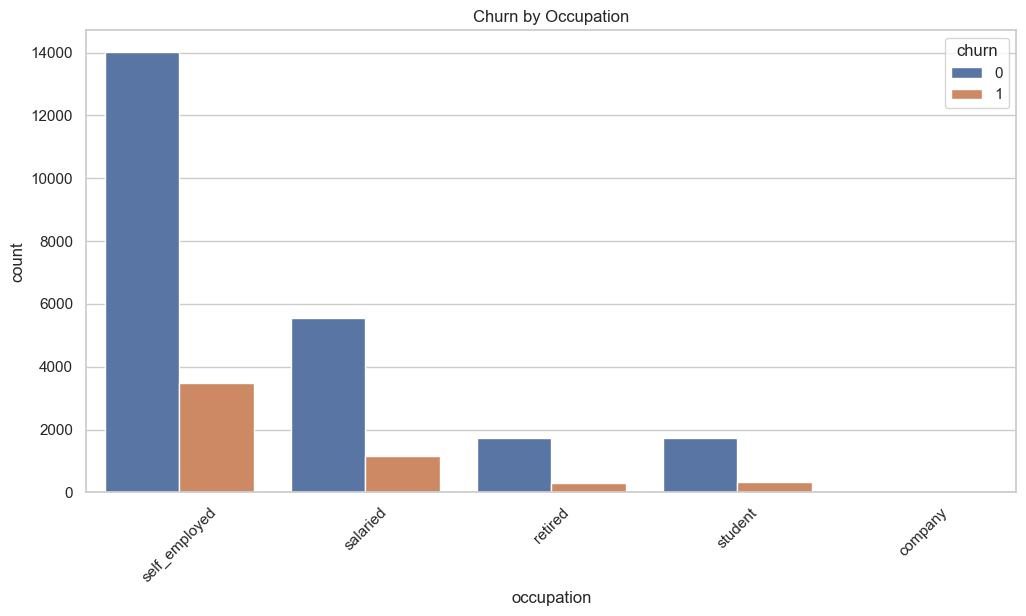

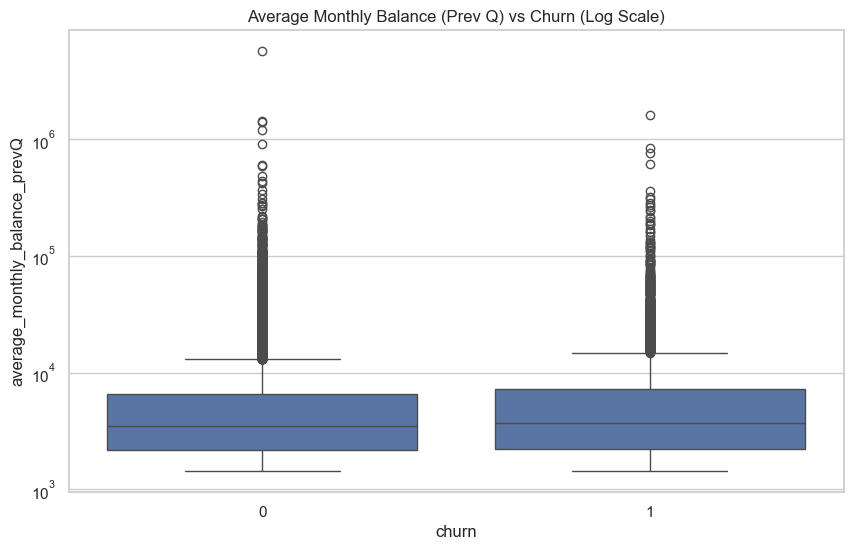

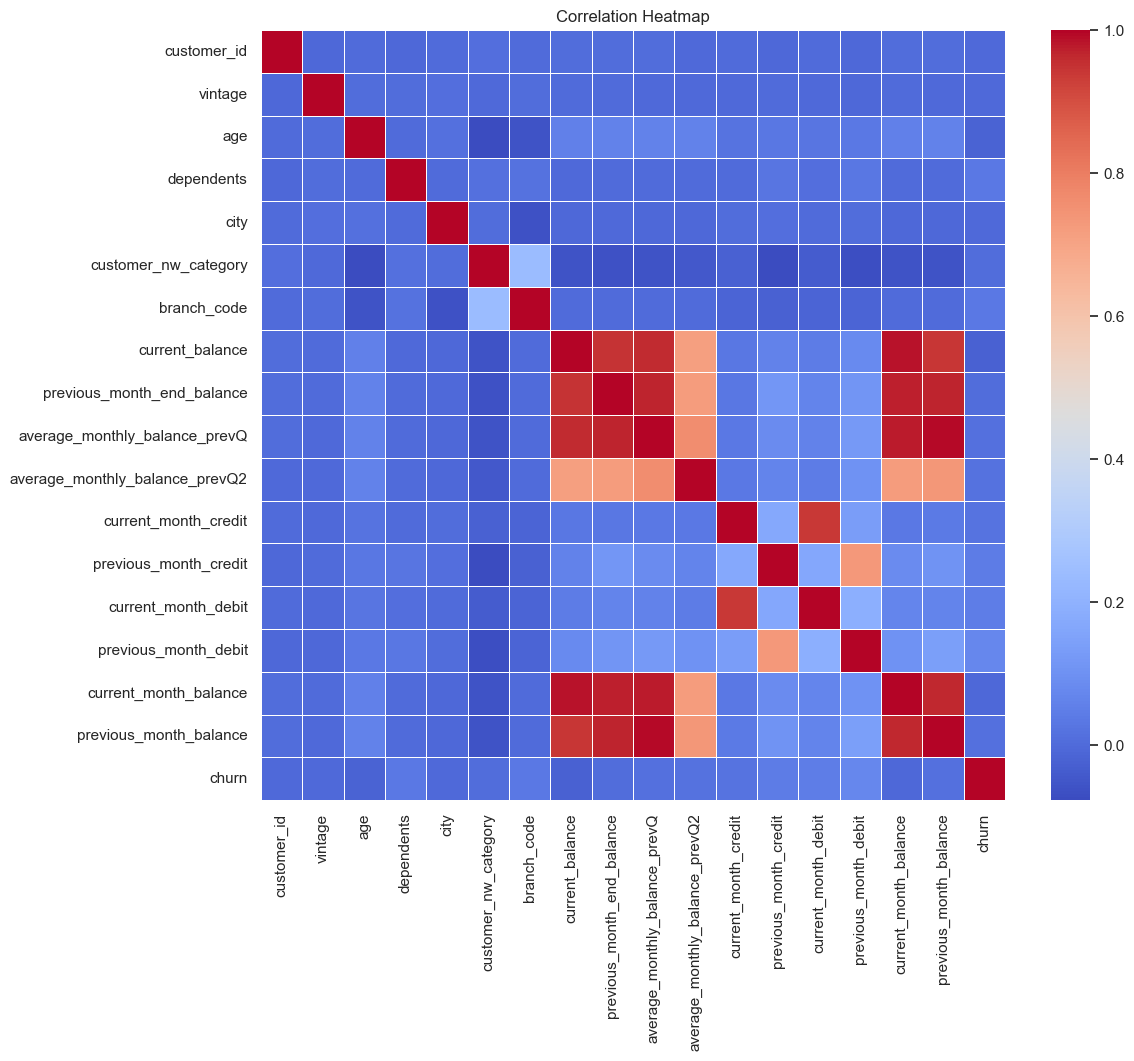

In [2]:

sns.set(style="whitegrid")

# 1. Distribution of Churn
plt.figure(figsize=(6, 4))
sns.countplot(x='churn', data=df)
plt.title('Distribution of Churn (Target Variable)')
plt.savefig('churn_distribution.png')

# 2. Age distribution
plt.figure(figsize=(10, 6))
sns.histplot(df['age'], bins=30, kde=True)
plt.title('Age Distribution of Customers')
plt.savefig('age_distribution.png')

# 3. Churn by Gender
plt.figure(figsize=(8, 5))
sns.countplot(x='gender', hue='churn', data=df)
plt.title('Churn by Gender')
plt.savefig('churn_by_gender.png')

# 4. Churn by Occupation
plt.figure(figsize=(12, 6))
sns.countplot(x='occupation', hue='churn', data=df)
plt.title('Churn by Occupation')
plt.xticks(rotation=45)
plt.savefig('churn_by_occupation.png')

# 5. Relationship between Average Monthly Balance (Prev Q) and Churn
# Using a log scale for balance due to high variance
plt.figure(figsize=(10, 6))
sns.boxplot(x='churn', y='average_monthly_balance_prevQ', data=df)
plt.yscale('log')
plt.title('Average Monthly Balance (Prev Q) vs Churn (Log Scale)')
plt.savefig('balance_vs_churn.png')

# 6. Correlation Heatmap (numerical variables)
plt.figure(figsize=(12, 10))
corr = df.select_dtypes(include=['float64', 'int64']).corr()
sns.heatmap(corr, annot=False, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.savefig('correlation_heatmap.png')

print("EDA plots generated.")

In [3]:

churn_rate = df['churn'].mean() * 100
print(f"Churn Rate: {churn_rate:.2f}%")

# Checking for 'NaT' in last_transaction
nat_count = (df['last_transaction'] == 'NaT').sum()
print(f"Number of 'NaT' strings in last_transaction: {nat_count}")

# Check occupation distribution
print("\nOccupation counts:")
print(df['occupation'].value_counts(dropna=False))

# Check gender distribution
print("\nGender counts:")
print(df['gender'].value_counts(dropna=False))

# Check net worth category
print("\nCustomer NW Category counts:")
print(df['customer_nw_category'].value_counts())

Churn Rate: 18.53%
Number of 'NaT' strings in last_transaction: 3223

Occupation counts:
occupation
self_employed    17476
salaried          6704
student           2058
retired           2024
NaN                 80
company             40
Name: count, dtype: int64

Gender counts:
gender
Male      16548
Female    11309
NaN         525
Name: count, dtype: int64

Customer NW Category counts:
customer_nw_category
2    14559
3    10112
1     3711
Name: count, dtype: int64
